In [1]:
##### DATA CLEANING #####

#---------------**1. ABSCHNITT DATA CLEANING**---------------

---



# Data Cleaning with Pandas



In [2]:
import pandas as pd

In [3]:
# orders.csv
url = "https://drive.google.com/file/d/1Vu0q91qZw6lqhIqbjoXYvYAQTmVHh6uZ/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders = pd.read_csv(path)

# orderlines.csv
url = "https://drive.google.com/file/d/1FYhN_2AzTBFuWcfHaRuKcuCE6CWXsWtG/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines = pd.read_csv(path)

Create a copy from orders and orderlines

In [4]:
orders_df = orders.copy()

In [5]:
orderlines_df = orderlines.copy()

## 1.&nbsp; Duplicates


In [6]:
# orders_df
orders_df.duplicated().sum()

np.int64(0)

In [7]:
# orderlines_df
orderlines_df.duplicated().sum()

np.int64(0)

We have no duplicate rows in either DataFrame. Easy, there is no problem to solve. Normally though, if there were some duplicates, we'd drop the extra rows.

# 2.&nbsp; `.info()`

In [8]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226909 entries, 0 to 226908
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      226909 non-null  int64  
 1   created_date  226909 non-null  object 
 2   total_paid    226904 non-null  float64
 3   state         226909 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.9+ MB


* `total_paid` has 5 missing values
* `created_date` should become datetime datatype

In [9]:
orderlines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293983 entries, 0 to 293982
Data columns (total 7 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                293983 non-null  int64 
 1   id_order          293983 non-null  int64 
 2   product_id        293983 non-null  int64 
 3   product_quantity  293983 non-null  int64 
 4   sku               293983 non-null  object
 5   unit_price        293983 non-null  object
 6   date              293983 non-null  object
dtypes: int64(4), object(3)
memory usage: 15.7+ MB


* `date` should be a datetime datatype
* `unit_price` should be a float datatype

## 3.&nbsp; Missing values

### 3.1.&nbsp; Orders
* `total_paid` has 5 missing values

In [10]:
num_missing = orders_df['total_paid'].isna().sum()
total_rows = orders_df.shape[0]
percent_missing = (100*num_missing/total_rows)
print(f"5 missing values represents {percent_missing:.5f}% of the rows in our DataFrame")

5 missing values represents 0.00220% of the rows in our DataFrame


 find out a percentage with .value_counts(normalize=True)`

In [11]:
orders_df['total_paid'].isna().value_counts(normalize=True)

,proportion
total_paid,
False,0.999978
True,0.000022


As there is such a tiny amount of missing values, we will simply delete these rows, as we have enough data without them.

In [12]:
orders_df = orders_df.dropna(axis=0)

### 3.2.&nbsp; Orderlines
There are no missing values in `orderlines_df`

In [13]:
#num_missing_2 = orderlines_df['total_paid'].isna().sum()

## 4.&nbsp; Datatypes

### 4.1.&nbsp; Orders
* `created_date` should become datetime datatype

In [14]:
orders_df["created_date"] = pd.to_datetime(orders_df["created_date"])

### 4.1.&nbsp; Orderlines
* `date` should be a datetime datatype
* `unit_price` should be a float datatype

#### 4.1.1.&nbsp; `date`

In [15]:
orderlines_df["date"] = pd.to_datetime(orderlines_df["date"])

#### 4.1.2.&nbsp;`unit_price`

In [16]:
#orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"])

When we try to convert `unit_price` to a numerical datatype, we receive a `ValueError` telling us that pandas doesn't understand the number `1.137.99`. This is probably because numbers cannot have multiple decimal points. Let's see if there are any other numbers like this.

In [17]:
# Count the number of decimal points in the unit_price
orderlines_df['unit_price'].str.count(r"\.").value_counts()

,count
unit_price,
1,257814
2,36169


Looks like over 36000 rows in `orderlines` are affected by this problem. Let's work out how much that is as a percentage of our total data.

In [18]:
# Count the rows with more than one `.`
mult_decimal_rows = (orderlines_df['unit_price'].str.count(r"\.")>1).sum()

# Find the percentage of corrupted rows
percent_corrupted = (100 * mult_decimal_rows / orderlines_df.shape[0])
print(f"{percent_corrupted:.2f}% of the rows in our DataFrame have multiple decimal points in the unit_price")

12.30% of the rows in our DataFrame have multiple decimal points in the unit_price


This is a bit of a tricky decision as 12.3% is a significant amount of our data... and we might even end up losing a larger portion of our data than this too. For the moment we will delete the rows as we only have 2 weeks for this project and I'd like some quick, accurate results to show.

Each row of `orderlines` represents a product in an order. For example, if order number 175 contained 3 seperate products, then order 175 would have 3 rows in `orderlines`, one row for each of the products. If 2 of those products have 'normal' prices (14.99, 15.85) and 1 has a price with 2 decimal points (1.137.99), we need to remove the whole order and not just the affected row. If we only remove the row with 2 decimal places then any later analysis about products and prices could be misleading.

We therefore need to find the order numbers associated with the rows that have 2 decimal points, and then remove all the associated rows.

In [19]:
# Boolean mask to find the orders that contain a price with multiple decimal points
multiple_decimal_mask = orderlines_df['unit_price'].str.count(r"\.") > 1

# Apply the boolean mask to the orderlines DataFrame. This way we can find the order_id of all the affected orders.
corrupted_order_ids = orderlines_df.loc[multiple_decimal_mask, "id_order"]

# Keep only the rows that do not have multiple decimal points
orderlines_df = orderlines_df.loc[~orderlines_df['id_order'].isin(corrupted_order_ids)]

In [20]:
orderlines_df.shape[0]

216250

We still have 216250 rows in orderlines to work with. This should be more than enough for our evaluation.

Now that all of the 2 decimal point prices have been removed, let's try again to convert the column `unit_price` to the correct datatype.

In [21]:
orderlines_df["unit_price"] = pd.to_numeric(orderlines_df["unit_price"])

It worked perfectly

#Clean the `products` DataFrame


In [22]:
# products.csv
url = "https://drive.google.com/file/d/1afxwDXfl-7cQ_qLwyDitfcCx3u7WMvkU/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products = pd.read_csv(path)

In [23]:
products_df = products.copy()

### Look for Duplicates

In [24]:
# Über 8.000 Duplicate Zeilen, die hiermit entfernt wurden
products_df = products_df.drop_duplicates()

products_df.duplicated().sum()

np.int64(0)

### Look for Missing values


In [25]:
# Bei desc, price und type fehlen werte
products_df.info()

## Mit for Schleife Anzahl der fehlenden Werte rausfinden
columns = ['desc', 'price', 'type']
total_rows = products_df.shape[0]

for col in columns:
  num_missing = products_df[col].isna().sum()
  percent_missing = (100* (num_missing / total_rows))
  print (f'Es existieren {num_missing} fehlende Werte bei der {col} Spalte. Dies entspricht {percent_missing:.5f}% von den gesamten Einträgen\n')

# Löschen der fehlenden Werte:
products_df = products_df.dropna(axis=0)




## OHNE SCHLEIFE
#desc
#num_missing_desc = products_df['desc'].isna().sum()
#total_rows = products_df.shape[0]
#percent_missing = (100* (num_missing_desc / total_rows))
#print (f'Es existieren {num_missing_desc} fehlende Werte bei der desc Spalte. Dies entspricht {percent_missing:.5f}% von den gesamnten Einträgen')

##price
#num_missing_price = products_df['price'].isna().sum()
#total_rows = products_df.shape[0]
#percent_missing = (100* (num_missing_price / total_rows))
#print (f'Es existieren {num_missing_price} fehlende Werte bei der price Spalte. Dies entspricht {percent_missing:.5f}% von den gesamnten Einträgen')


##type
#num_missing_type = products_df['type'].isna().sum()
#total_rows = products_df.shape[0]
#percent_missing = (100* (num_missing_type / total_rows))
#print (f'Es existieren {num_missing_type} fehlende Werte bei der type Spalte. Dies entspricht {percent_missing:.5f}% von den gesamnten Einträgen')

<class 'pandas.core.frame.DataFrame'>
Index: 10580 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          10580 non-null  object
 1   name         10580 non-null  object
 2   desc         10573 non-null  object
 3   price        10534 non-null  object
 4   promo_price  10580 non-null  object
 5   in_stock     10580 non-null  int64 
 6   type         10530 non-null  object
dtypes: int64(1), object(6)
memory usage: 661.2+ KB
Es existieren 7 fehlende Werte bei der desc Spalte. Dies entspricht 0.06616% von den gesamten Einträgen

Es existieren 46 fehlende Werte bei der price Spalte. Dies entspricht 0.43478% von den gesamten Einträgen

Es existieren 50 fehlende Werte bei der type Spalte. Dies entspricht 0.47259% von den gesamten Einträgen



### Check / Change Data types

In [26]:
# Vorher: 10580 Werte
# Nach 1. Bereinigung mit price: 10203 Werte

#price und promo_price müssen Zahlen sein statt String
products_df.info()

#wieviele . in price
products_df['price'].str.count(r"\.").value_counts()

#Zähle Zeilen mit mehr als 1 .
mult_decimal_rows = (products_df['price'].str.count(r"\.")>1).sum()


#Prozentzahl rausfinden von kaputten Zeilen wegen .
percent_corrupted = (100 * (mult_decimal_rows / products_df.shape[0]))
print(f"{percent_corrupted:.2f}% of the rows in our DataFrame have multiple decimal points in the Sku")

# Maske erstellen um Bestellungen rauszufinden die 2x. . haben
multiple_decimal_mask = products_df['price'].str.count(r"\.") > 1

# Die Maske anwenden, um die SKU rauszufinden der beschädigten Zahlen
corrupted_product_sku = products_df.loc[multiple_decimal_mask, "sku"]

# Nur die Zahlen behalten die normal sind und nicht 2x. . haben
products_df = products_df.loc[~products_df['sku'].isin(corrupted_product_sku)]

# Price umwandeln als Zahl
products_df['price'] = pd.to_numeric(products_df['price'])

products_df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 10477 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sku          10477 non-null  object
 1   name         10477 non-null  object
 2   desc         10477 non-null  object
 3   price        10477 non-null  object
 4   promo_price  10477 non-null  object
 5   in_stock     10477 non-null  int64 
 6   type         10477 non-null  object
dtypes: int64(1), object(6)
memory usage: 654.8+ KB
3.56% of the rows in our DataFrame have multiple decimal points in the Sku
<class 'pandas.core.frame.DataFrame'>
Index: 10104 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          10104 non-null  object 
 1   name         10104 non-null  object 
 2   desc         10104 non-null  object 
 3   price        10104 non-null  float64
 4   promo_price  10104 non-null  object 
 5  

In [27]:
# Umwandlung von promo_price als Zahl

# Vorher 10203 Einträge mit: products_df.shape
# promo_price hat noch komische Werte. Normaler Price ist bereits bereinigt
# Am Ende nur noch 5.820 Werte. Es wurden 4383 werte gelöscht.



#wieviele . in promo_price
products_df['promo_price'].str.count(r"\.").value_counts()

#Zähle Zeilen mit mehr als 1 .
mult_decimal_rows2 = (products_df['promo_price'].str.count(r"\.")>1).sum()

#Prozentzahl rausfinden von kaputten Zeilen wegen .
percent_corrupted2 = (100 * (mult_decimal_rows2 / products_df.shape[0]))
print(f"{percent_corrupted2:.2f}% of the rows in our DataFrame have multiple decimal points in the Sku")

# Maske erstellen um Bestellungen rauszufinden die 2x. . haben
multiple_decimal_mask2 = products_df['promo_price'].str.count(r"\.") > 1

# Die Maske anwenden, um die SKU rauszufinden der beschädigten Zahlen
corrupted_product_sku2 = products_df.loc[multiple_decimal_mask2, "sku"]
corrupted_product_sku2

# Nur die Zahlen behalten die normal sind und nicht 2x. . haben
products_df = products_df.loc[~products_df['sku'].isin(corrupted_product_sku2)]

# Price umwandeln als Zahl
products_df['promo_price'] = pd.to_numeric(products_df['promo_price'])

products_df.info()

products_df.shape


42.40% of the rows in our DataFrame have multiple decimal points in the Sku
<class 'pandas.core.frame.DataFrame'>
Index: 5820 entries, 0 to 19325
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku          5820 non-null   object 
 1   name         5820 non-null   object 
 2   desc         5820 non-null   object 
 3   price        5820 non-null   float64
 4   promo_price  5820 non-null   float64
 5   in_stock     5820 non-null   int64  
 6   type         5820 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 363.8+ KB


(5820, 7)

We delete Promo Price

In [28]:
products_df = products_df.drop('promo_price', axis = 1)

products_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5820 entries, 0 to 19325
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       5820 non-null   object 
 1   name      5820 non-null   object 
 2   desc      5820 non-null   object 
 3   price     5820 non-null   float64
 4   in_stock  5820 non-null   int64  
 5   type      5820 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 318.3+ KB


# Brands

In [29]:
# brands.csv
url = "https://drive.google.com/file/d/1LI129y6gx5wAJaJfPpzo12mvCz7aWOel/view?usp=share_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands = pd.read_csv(path)

In [30]:
brands_df = brands.copy()

In [31]:
# keine Dupilkate
brands_df.duplicated().sum()

np.int64(0)

In [32]:
# keine leeren Werte
brands_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187 entries, 0 to 186
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   short   187 non-null    object
 1   long    187 non-null    object
dtypes: object(2)
memory usage: 3.1+ KB


#Download the Data after first cleanup

In [33]:
from google.colab import files

orders_df.to_csv("orders_cl.csv", index=False)
files.download("orders_cl.csv")

orderlines_df.to_csv("orderlines_cl.csv", index=False)
files.download("orderlines_cl.csv")

products_df.to_csv("products_cl.csv", index=False)
files.download("products_cl.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
##### Quality Assesment #####

#---------------**2. ABSCHNITT QualityAssesment**---------------

---

# Quality Assessment
Now we check how reliable the data is.

In [35]:
import pandas as pd

Load our cleaned DataFrames

In [36]:
# orders_cl.csv
url = "https://drive.google.com/file/d/1QiWLCP_60mpXEYS6A1YEH3S0Whg288xy/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv
url = "https://drive.google.com/file/d/1hu2Kh3rAOQVC0gGLQN8Zs_HMboVXlu2B/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1IPnKYLSnrST0HBZMeSeNrhFfWU31QvwB/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

## 1.&nbsp; Define Pandas display format

In [37]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

## 2.&nbsp; Exclude unwanted orders

In [38]:
# Kopie erstellen orders_df von orders_cl
orders_df = orders_cl.copy()

# Kopie erstellen orderlines_df von orderlines_cl
orderlines_df = orderlines_cl.copy()


# Nur Bestellungen behalten mit Status 'Completed'
orders_df = orders_df.loc[orders_df['state'] == 'Completed']

# 45242 Bestellunegn übrig
orders_df.shape[0]

# Nur orders haben die in orderlines vorhanden sind --> Inner Merge
orders_df
orderlines_df

orders_and_orderlines_df = orders_df.merge(orderlines_df, left_on = 'order_id', right_on = 'id_order', how = 'inner')

# Nur eizigartige Order Ids
# order_ids_einzigartig = orders_and_orderlines_df['order_id'].unique()
# order_ids_einzigartig

## 3.&nbsp; Exclude orders with unknown products


In [39]:
# Kopie erstellen products_df von products_cl
products_df = products_cl.copy()

#Finde Bestellungen IDs mit unbekannten SKUs
kaputte_bestellungen_id = orderlines_df.loc[~orderlines_df['sku'].isin(products_df['sku']), 'id_order']
kaputte_bestellungen_id.shape[0]

# Löschen der kaputten ID Werte bei orderlines. 205580 werte bei orderlines übrig
orderlines_df = orderlines_df.loc[~orderlines_df['id_order'].isin(kaputte_bestellungen_id)]
orderlines_df.shape[0]

# Löschen der kaputten ID Werte bei orders. 85407 werte bei orders übrig
orders_df = orders_df.loc[~orders_df['order_id'].isin(kaputte_bestellungen_id)]

# Anzahl prüfen
orders_df.shape
orderlines_df.shape

(205580, 7)

## 4.&nbsp; Explore the revenue from different tables

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [40]:
orderlines_df['unit_price_total'] = orderlines_df['unit_price'] * orderlines_df['product_quantity']

orderlines_df

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
0,1119109,299539,0,1,OTT0133,18.99,2017-01-01 00:07:19,18.99
1,1119110,299540,0,1,LGE0043,399.00,2017-01-01 00:19:45,399.00
2,1119111,299541,0,1,PAR0071,474.05,2017-01-01 00:20:57,474.05
3,1119112,299542,0,1,WDT0315,68.39,2017-01-01 00:51:40,68.39
4,1119113,299543,0,1,JBL0104,23.74,2017-01-01 01:06:38,23.74
...,...,...,...,...,...,...,...,...
216245,1650199,527398,0,1,JBL0122,42.99,2018-03-14 13:57:25,42.99
216246,1650200,527399,0,1,PAC0653,141.58,2018-03-14 13:57:34,141.58
216247,1650201,527400,0,2,APP0698,9.99,2018-03-14 13:57:41,19.98
216248,1650202,527388,0,1,BEZ0204,19.99,2018-03-14 13:58:01,19.99


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [41]:
# Ganze DF aber gruppiert nach id_order
#orderlines_df.groupby('id_order').sum('unit_price_total')

# dataframe gruppiert nach id_order
orderlines_grouped = orderlines_df.groupby('id_order', as_index = False)['unit_price_total'].sum()

orderlines_grouped


,id_order,unit_price_total
0,241319,44.99
1,241355,135.98
2,241423,129.16
3,242832,10.77
4,243330,77.99
...,...,...
163880,527397,42.99
163881,527398,42.99
163882,527399,141.58
163883,527400,19.98


### What is the average difference between `total_paid` and `unit_price_total`?

In [42]:
# The grouped orderlines table can be merged with the orders table to easily compare the numbers:

# Merge machen von gruppierte orderlines Tabelle und orders Tabelle
orderlinesgrouped_and_orders_df = orders_df.merge(orderlines_grouped, left_on = 'order_id', right_on = 'id_order', how = 'inner')
orderlinesgrouped_and_orders_df

# durchschnittliche differenz von total_paid und unit_price_total
avg_dif = (orderlinesgrouped_and_orders_df['total_paid'] - orderlinesgrouped_and_orders_df['unit_price_total']).mean()

# 3.64 durchschnittliche Differenz
print(round(avg_dif,2))


4.47


### What is the distribution of these differences?

Text(0, 0.5, 'Frequency')

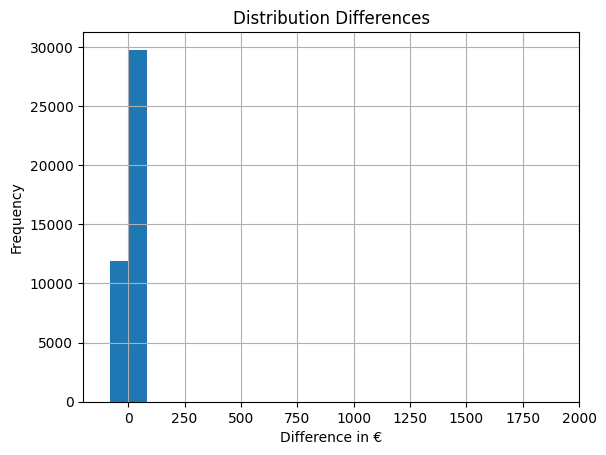

In [43]:
# Standarbabweichung berechnen
std = (orderlinesgrouped_and_orders_df['total_paid'] - orderlinesgrouped_and_orders_df['unit_price_total']).std()
std


# Differenz Werte abspeichern
differences = (orderlinesgrouped_and_orders_df['total_paid'] - orderlinesgrouped_and_orders_df['unit_price_total'])
differences.describe()

# Differenz abspeichern als Spalte in orderlinesgrouped_and_orders Dataframe
orderlinesgrouped_and_orders_df['difference'] = differences
orderlinesgrouped_and_orders_df

# Differenz Werte als Histogramm
import matplotlib.pyplot as plt
differences.hist(bins=50)
plt.xlim(-200, 2000)
plt.title('Distribution Differences')
plt.xlabel ('Difference in €')
plt.ylabel('Frequency')

#differences.value_counts().sort_index().head(20)


# Same with Price. We perform a similar process comparing orderlines.unit_price with products.price

27.88


Text(0, 0.5, 'Frequency')

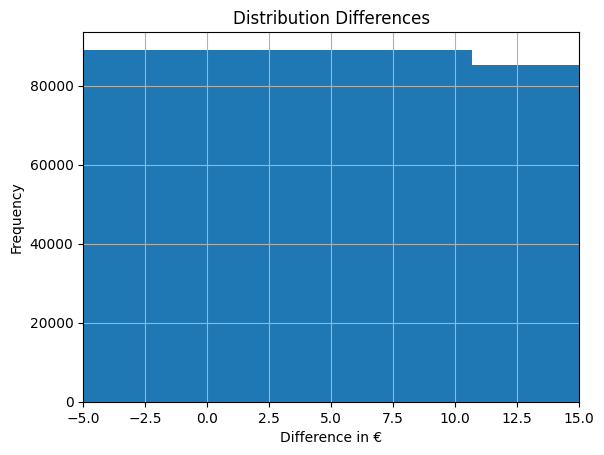

In [44]:
# The orderlines table can be merged with the products table on sku to easily compare the numbers:

# Merge machen von products Tabelle und orderlines Tabelle
products_and_orderlines_df = products_df.merge(orderlines_df , left_on = 'sku', right_on = 'sku', how = 'inner')
products_and_orderlines_df


# durchschnittliche Differenz von price und unit_price
avg_dif2 = (products_and_orderlines_df['price'] - products_and_orderlines_df['unit_price']).mean()
avg_dif2

# negative Werte sehen von der Differenz von price und unit_price
products_and_orderlines_df.loc[(products_and_orderlines_df['price'] < products_and_orderlines_df['unit_price'])]


# 27.88 durchschnittliche Differenz
print(round(avg_dif2,2))

# Standarbabweichung berechnen: 91
std2 = (products_and_orderlines_df['price'] - products_and_orderlines_df['unit_price']).std()
std2

# Differenz Werte
differences2 = (products_and_orderlines_df['price'] - products_and_orderlines_df['unit_price'])
differences2.describe()

# Differenz2 als neue Spalte
products_and_orderlines_df['Differenz_price_und_Unit_price'] = products_and_orderlines_df['price'] - products_and_orderlines_df['unit_price']
products_and_orderlines_df

# Ausreißer sehen positive Werte
products_and_orderlines_df.loc[(products_and_orderlines_df['Differenz_price_und_Unit_price'] > 100), :]

# Ausreißer sehen negative Werte
products_and_orderlines_df.loc[(products_and_orderlines_df['Differenz_price_und_Unit_price'] < -50), :]

# Differenz Werte als Histogramm
import matplotlib.pyplot as plt
differences2.hist(bins=200)
plt.xlim(-5, 15)
plt.title('Distribution Differences')
plt.xlabel ('Difference in €')
plt.ylabel('Frequency')

**products.price **–> this is the original price of a product, without any discount or promotion.

**orderlines.unit_price **–> this is the actual price at which a product has been sold. It should roughly match the price in the products table, but there might be deviations, as discounts get applied here.
**(Was ich erwartet habe was jemand zahlt)**

**orders.total_paid **–> this is the total amount of the full order. It should roughly translate to the sum of all unitary prices, multiplied by the amount of each product purchased (orderlines.product_quantity). The key word here is, again, roughly: the total amount of the order might include shipping costs or vouchers.
**(Was jemand wirklich gezahlt hat)**

### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

In [45]:
# your explanation here

# Gutscheine
# Versandkosten
# Rabatte
# Rückerstattungen oder Teilrückerstattungen
# Steuern
# Fehler in den Dateien

### If there are differences that you can’t explain: what should you do with these orders?

We delete them. Wit a rule. There's a rule of thumb, that anything:

lower than the 25% quartile - (1.5 x interquartile range), or

higher than the 75% quartile + (1.5 x interquartile range) is an outlier.

Let's use this rule to try and exclude any corrupted data.

In [46]:
### Für Difference (total paid - unit price total) Gesamtpreise vergleichen von orders und orderlines

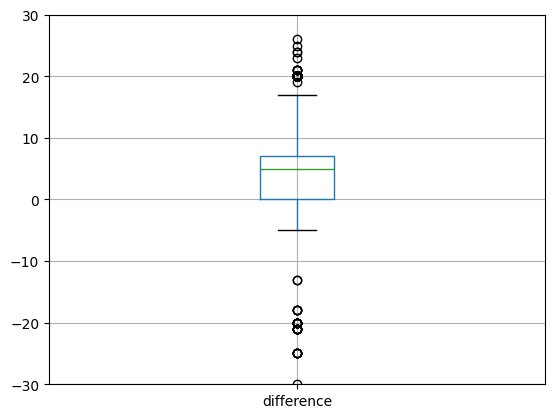

In [47]:
#Boxplot
ax = orderlinesgrouped_and_orders_df.boxplot("difference");
ax.set_ylim(-30, +30)
plt.show()


In [48]:
# calculate the quartiles
Q1 = orderlinesgrouped_and_orders_df["difference"].quantile(0.25)
Q3 = orderlinesgrouped_and_orders_df["difference"].quantile(0.75)
Q1, Q3

# calculate the interquartile range
IQR = Q3-Q1
IQR

# lower boundary
Q1 - 1.5*IQR

# upper boundary
Q3 + 1.5*IQR

# filter the DataFrame to include only "non-outliers"
diff_no_outliers_df = orderlinesgrouped_and_orders_df.loc[
    (orderlinesgrouped_and_orders_df["difference"] >= (Q1 - 1.5*IQR))
    &
    (orderlinesgrouped_and_orders_df["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]



Let's look at the distribution again to see the effect of removing the outliers.

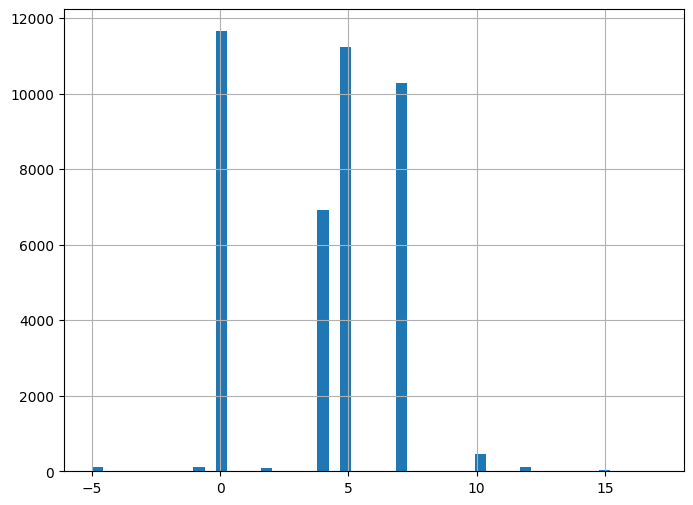

In [49]:
diff_no_outliers_df.difference.hist(bins= 50, figsize=(8,6));

<Axes: >

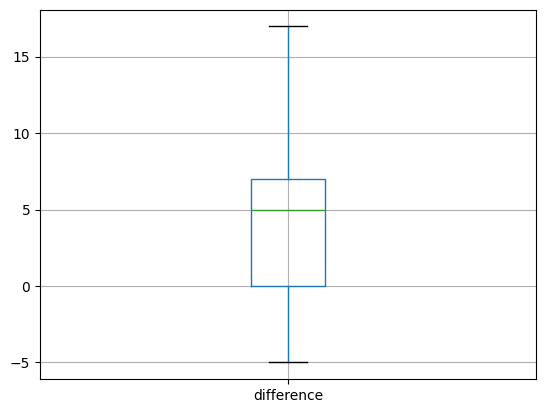

In [50]:
diff_no_outliers_df.boxplot("difference")

This looks much more like what we would expect: a small difference, but nothing extreme.



Now we need to remove these orders with extreme differences from our `orders_lines_merged` DataFrame.

In [51]:
normal_diff_list = diff_no_outliers_df["order_id"]

In [52]:
orders_qu_bereinigt_komplett = orders_df.loc[orders_df["order_id"].isin(normal_diff_list), :]
orderlines_qu_bereinigt_komplett = orderlines_df.loc[orderlines_df["id_order"].isin(normal_diff_list), :]

In [53]:
orders_qu_bereinigt_komplett["order_id"].nunique(), orderlines_qu_bereinigt_komplett["id_order"].nunique()

(40985, 40985)

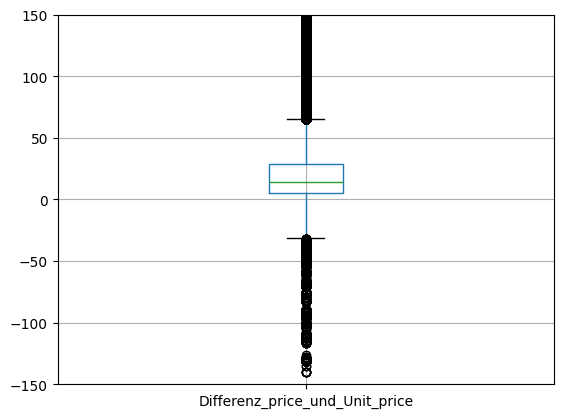

In [54]:
### Für Differences 2 (price - unit price ) Produkt Stückpreise vergleichen von products und orderlines

#Boxplot
ax = products_and_orderlines_df.boxplot("Differenz_price_und_Unit_price");
ax.set_ylim(-150, +150)
plt.show()

In [55]:
# calculate the quartiles
Q1 = products_and_orderlines_df["Differenz_price_und_Unit_price"].quantile(0.25)
Q3 = products_and_orderlines_df["Differenz_price_und_Unit_price"].quantile(0.75)
Q1, Q3

# calculate the interquartile range
IQR = Q3-Q1
IQR

# lower boundary
Q1 - 1.5*IQR

# upper boundary
Q3 + 1.5*IQR

# filter the DataFrame to include only "non-outliers"
diff2_no_outliers_df = products_and_orderlines_df.loc[
    (products_and_orderlines_df["Differenz_price_und_Unit_price"] >= (Q1 - 1.5*IQR))
    &
    (products_and_orderlines_df["Differenz_price_und_Unit_price"] <= (Q3 + 1.5*IQR))
    ,
    :]

Let's look at the distribution again to see the effect of removing the outliers.

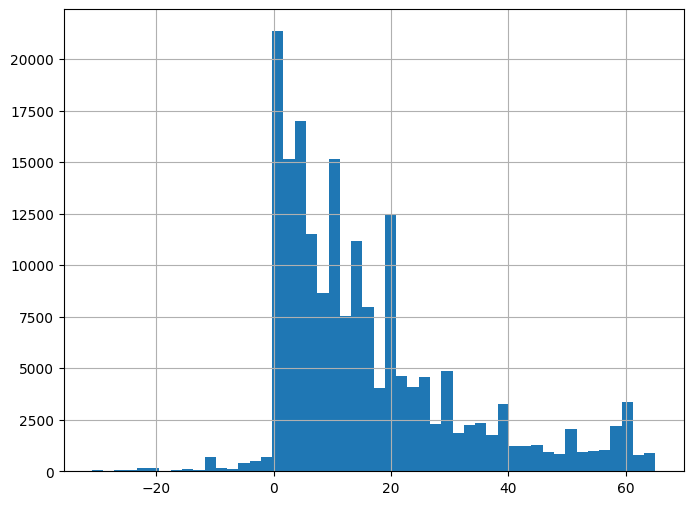

In [56]:
diff2_no_outliers_df.Differenz_price_und_Unit_price.hist(bins= 50, figsize=(8,6));

<Axes: >

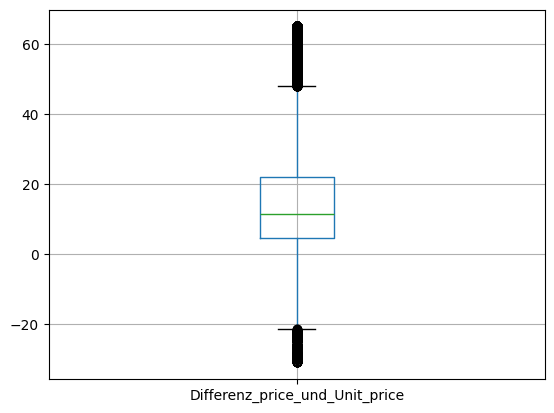

In [57]:
diff2_no_outliers_df.boxplot("Differenz_price_und_Unit_price")

This looks much more like what we would expect: a small difference, but nothing extreme.

Now we need to remove these orders (sku) with extreme differences from our `products` DataFrame.

In [58]:
normal_diff_list2 = diff2_no_outliers_df["sku"]

In [59]:
products_qu_bereinigt_komplett = products_df.loc[products_df["sku"].isin(normal_diff_list2), :]

In [60]:
products_qu_bereinigt_komplett["sku"].nunique()

5656

#Download Quality Controlled Data

In [61]:
from google.colab import files

orders_qu_bereinigt_komplett.to_csv("orders_qu_bereinigt_komplett.csv", index=False)
files.download("orders_qu_bereinigt_komplett.csv")

orderlines_qu_bereinigt_komplett.to_csv("orderlines_qu_bereinigt_komplett.csv", index=False)
files.download("orderlines_qu_bereinigt_komplett.csv")

products_qu_bereinigt_komplett.to_csv("products_qu_bereinigt_komplett.csv", index=False)
files.download("products_qu_bereinigt_komplett.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
##### Categorys #####

#---------------**3. ABSCHNITT Categorys**---------------

---

##Searching for the category

For this code we are only going to use the products DataFrame.

In [63]:
import pandas as pd

In [64]:
# products_cl.csv
url = "https://drive.google.com/file/d/1IPnKYLSnrST0HBZMeSeNrhFfWU31QvwB/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

In [65]:
product_category_df = products_cl.copy()

In [66]:
product_category_df.head()

,sku,name,desc,price,in_stock,type
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364


**Start with Categorys:**


In [67]:
from numpy._core.fromnumeric import prod
# your code here
# Kategorien direkt mit type

# Products erstellen mit leere Spalte Category
product_category_df['category'] = ''
product_category_df.head()

# Wieviele Kategorien von einzigartigen types brauche ich, um die meisten Produkte abzudecken
n = 31
print(f"With the {n} largest types, we account for {((product_category_df.groupby('type').count().nlargest(n, 'sku')['sku'].sum()) / (product_category_df.shape[0]) * 100).round(2)}% of all products.")

# Die 30 größten types herausfinden
product_category_df.groupby('type').count().nlargest(30, 'sku')

# Den 1. Type prüfen was für Produkte drinne sind. Sieht nach phone case aus
product_category_df.loc[product_category_df['type'] == '11865403'].sample(10)

# Category umbenennen für diesen type
product_category_df.loc[product_category_df['type'] == '11865403', 'category'] = 'phone case'

product_category_df.loc[(product_category_df['name'].str.contains('iphone', case = False, na = False)) & (product_category_df['price'] > 450), :]

With the 31 largest types, we account for 79.13% of all products.


,sku,name,desc,price,in_stock,type,category
579,APP0675,Apple iPhone 5S 32GB Space Gray,New Free iPhone 5S 32GB (ME435Y / A).,559.00,0,NaN,
956,APP0823,Apple iPhone 6 16GB Silver,New iPhone 6 16GB Free (MG482QL / A).,639.00,0,NaN,
961,APP0829,Apple iPhone 6 Plus 16GB Silver,New iPhone 6 Plus 16G Free (MGA92QL / A).,749.00,0,NaN,
962,APP0822,Apple iPhone 6 16GB Space Gray,New iPhone 6 16GB Free (MG472QL / A).,639.00,0,NaN,
963,APP0825,Apple iPhone 6 64GB Space Gray,New iPhone 6 64GB Free (MG4F2QL / A).,749.00,0,NaN,
964,APP0826,Apple iPhone 6 64GB Silver,New iPhone 6 64GB Free (MG4H2QL / A).,749.00,0,NaN,
965,APP0828,Apple iPhone 6 Plus 16GB Space Gray,New 16GB iPhone 6 Plus Free (MGA82QL / A).,749.00,0,NaN,
1042,APP0856,Apple iPhone 6 128GB Gold,New Free iPhone 6 128GB (MG4E2QL / A).,899.00,0,NaN,
1043,APP0857,Apple iPhone 6 Plus 64GB Space Gray,New iPhone 6 Plus 64GB Free (MGAH2QL / A).,859.00,0,NaN,
1044,APP0858,Apple iPhone 6 Plus 64GB Silver,New 64GB iPhone 6 Plus Free (MGAJ2QL / A).,859.00,0,NaN,


In [68]:
# für restliche 29 types:

# Den 2. Type prüfen was für Produkte drinne sind. Sieht nach Server aus
product_category_df.loc[product_category_df['type'] == '12175397'].sample(10)

# Den 3. Type prüfen was für Produkte drinne sind. Sieht nach Open Produkte aus
product_category_df.loc[product_category_df['type'] == '1298'].sample(10)

# Den 4. Type prüfen was für Produkte drinne sind. Sieht nach Festplatten Hard Drive aus
product_category_df.loc[product_category_df['type'] == '11935397'].sample(10)

# Den 5. Type prüfen was für Produkte drinne sind. Sieht nach Technischer Zubehör aus
product_category_df.loc[product_category_df['type'] == '11905404'].sample(10)

# Den 6. Type prüfen was für Produkte drinne sind. Sieht nach Apple Mac aus
product_category_df.loc[product_category_df['type'] == '1282'].sample(10)

# Den 7. Type prüfen was für Produkte drinne sind. Sieht nach ipad Case aus
product_category_df.loc[product_category_df['type'] == '12635403'].sample(10)

# Den 8. Type prüfen was für Produkte drinne sind. Sieht nach Cover for Mac Book aus
product_category_df.loc[product_category_df['type'] == '13835403'].sample(10)

# Den 9. Type prüfen was für Produkte drinne sind. Sieht nach Apple i Mac Device aus
product_category_df.loc[product_category_df['type'] == '5,74E+15'].sample(10)

# Den 10. Type prüfen was für Produkte drinne sind. Sieht nach Mac Memory aus
product_category_df.loc[product_category_df['type'] == '1364'].sample(10)

# Den 11. Type prüfen was für Produkte drinne sind. Sieht nach Adapter aus
product_category_df.loc[product_category_df['type'] == '12585395'].sample(10)

# Den 12. Type prüfen was für Produkte drinne sind. Sieht nach Monitor aus
product_category_df.loc[product_category_df['type'] == '1296'].sample(10)

# Den 13. Type prüfen was für Produkte drinne sind. Sieht nach Used Apple Acessoire aus
product_category_df.loc[product_category_df['type'] == '1325'].sample(10)

# Den 14. Type prüfen was für Produkte drinne sind. Sieht nach Headset & Headphone aus
product_category_df.loc[product_category_df['type'] == '5384'].sample(10)

# Den 15. Type prüfen was für Produkte drinne sind. Sieht nach SSD Festplatte aus
product_category_df.loc[product_category_df['type'] == '1433'].sample(10)

# Den 16. Type prüfen was für Produkte drinne sind. Sieht nach SSD Festplatte aus
product_category_df.loc[product_category_df['type'] == '12215397'].sample(10)

# Den 17. Type prüfen was für Produkte drinne sind. Sieht nach Speaker Wireless & Bluetooth aus
product_category_df.loc[product_category_df['type'] == '5398'].sample(10)

# Den 18. Type prüfen was für Produkte drinne sind. Sieht nach Mac Book Pro aus
product_category_df.loc[product_category_df['type'] == '1,02E+12'].sample(10)

# Den 19. Type prüfen was für Produkte drinne sind. Sieht nach Repair Service aus
product_category_df.loc[product_category_df['type'] == '1,44E+11'].sample(10)

# Den 20. Type prüfen was für Produkte drinne sind. Sieht nach Micro Memory Card aus
product_category_df.loc[product_category_df['type'] == '57445397'].sample(10)

# Den 21. Type prüfen was für Produkte drinne sind. Sieht nach Wifi Adapter aus
product_category_df.loc[product_category_df['type'] == '1334'].sample(10)

# Den 22. Type prüfen was für Produkte drinne sind. Sieht nach Mac Book Pro aus
product_category_df.loc[product_category_df['type'] == '2158'].sample(10)

# Den 23. Type prüfen was für Produkte drinne sind. Sieht nach Apple Watch Accessiore aus
product_category_df.loc[product_category_df['type'] == '2449'].sample(10)

# Den 24. Type prüfen was für Produkte drinne sind. Sieht nach Festplatten & Hard Drive aus
product_category_df.loc[product_category_df['type'] == '12655397'].sample(10)

# Den 25. Type prüfen was für Produkte drinne sind. Sieht nach Digital Pen aus
product_category_df.loc[product_category_df['type'] == '1229'].sample(10)

# Den 26. Type prüfen was für Produkte drinne sind. Sieht nach Graphic Adapter aus
product_category_df.loc[product_category_df['type'] == '12995397'].sample(10)

# Den 27. Type prüfen was für Produkte drinne sind. Sieht External Battery nach aus
product_category_df.loc[product_category_df['type'] == '1515'].sample(10)

# Den 28. Type prüfen was für Produkte drinne sind. Sieht nach Charger aus
product_category_df.loc[product_category_df['type'] == '13615399'].sample(10)

# Den 29. Type prüfen was für Produkte drinne sind. Sieht nach Screen Protector aus
product_category_df.loc[product_category_df['type'] == '13555403'].sample(10)

# Den 30. Type prüfen was für Produkte drinne sind. Sieht nach Graphic Tablet other Brands aus
product_category_df.loc[product_category_df['type'] == '1405'].sample(10)

,sku,name,desc,price,in_stock,type,category
6797,WAC0217-A,Open - Intuos Pro Paper M South Graphics Table...,Large graphic tablet allows you to design on p...,429.90,0,1405,
471,WAC0133,Education - Wacom Intuos Pro M Graphics Tablet,Exclusive discount for students and teachers.,349.99,0,1405,
472,WAC0135,Education - Wacom Intuos Pro L Graphics Tablet,Exclusive discount for students and teachers.,479.49,0,1405,
9905,WAC0249,Wacom Intuos S graphics tablet Black,small graphic tablet with creative art softwar...,79.00,1,1405,
2455,WAC0172,Education - Wacom Intuos Creative Art Pen & To...,Graphic tablet with pen and touch digital tool...,99.99,0,1405,
2452,WAC0176,Wacom Bamboo Spark snap-fit ​​iPad Air 2,Bloc Smart notes.,159.90,0,1405,
9909,WAC0257,Wacom Intuos Graphics Tablet M Bluetooth Pista...,Medium-edge graphics tablet with Bluetooth int...,199.00,1,1405,
6517,WAC0230,Wacom Intuos Pen & Touch 3D Creative Medium Black,graphics tablet with ExpressKeys keys multi pe...,199.99,0,1405,
2450,WAC0169,Wacom Intuos graphics tablet Photo Small Black,Graphical touch tablet with pen and digital to...,99.99,0,1405,
469,WAC0132,Wacom Intuos Pro S Graphics Tablet - Education,Exclusive discount for students and teachers.,224.99,1,1405,


Restliche Kategorien in Data Frame. Somit 31 Kategorien gesamt, da extra Kategorie für iphone gemacht wurde

In [69]:
# + iphone als extra Type. Somit insgesamt 31 Types
product_category_df.loc[(product_category_df['name'].str.contains('iphone', case = False, na = False)) & (product_category_df['price'] > 450), 'category'] = 'iPhone'



In [70]:
# Die type namen die herausgefunden wurden mit einer Schleife in den Data Frame bei Category anwenden und umbenennen

# Liste erstellen mit Kategorien Länge 29
categorys = ['Server', 'Open Produkte', 'Festplatten & Hard Drive', 'Technischer Zubehör', 'Apple Mac', 'ipad Case', 'Cover for Mac Book', 'Apple iMac Device', 'Mac Memory', 'Adapter', 'Monitor', 'Used Apple Accessoire', 'Headset & Headphone', 'SSD Festplatte', 'SSD Festplatte', 'Speaker Wireless & Bluetooth', 'Mac Book Pro', 'Repair Service', 'Micro Memory Card', 'Wifi Adapter', 'Mac Book Pro', 'Apple Watch Accessiore', 'Festplatten & Hard Drive', 'Digital Pen', 'Graphic Adapter', 'External Battery', 'Charger', 'Screen Protector', 'Graphic Tablet other Brands']
len(categorys)

#Liste erstellen mit Types Länge 29:
types = ['12175397', '1298', '11935397', '11905404', '1282', '12635403', '13835403', '5,74E+15', '1364', '12585395', '1296', '1325', '5384', '1433', '12215397', '5398', '1,02E+12', '144E+11', '57445397', '1334', '2158', '2449', '12655397', '1229', '12995397', '1515', '13615399', '13555403', '1405']
len(types)

# Schleife
for typ, category in zip(types, categorys):
    product_category_df.loc[product_category_df['type'] == typ, 'category'] = category

# Beispiel Werte anzeigen lassen
product_category_df.sample(10)

# Werte und Kategorien sehen
product_category_df['category'].value_counts()

#9992 Gesamte Werte
product_category_df.shape[0]

#Die restlichen Werte als Kategorie other
product_category_df.loc[product_category_df['category'] == '', 'category'] = 'other'

product_category_df


,sku,name,desc,price,in_stock,type,category
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,other
1,APP0023,Apple Mac Keyboard Keypad Spanish,USB ultrathin keyboard Apple Mac Spanish.,59.00,0,13855401,other
2,APP0025,Mighty Mouse Apple Mouse for Mac,mouse Apple USB cable.,59.00,0,1387,other
3,APP0072,Apple Dock to USB Cable iPhone and iPod white,IPhone dock and USB Cable Apple iPod.,25.00,0,1230,other
4,KIN0007,Mac Memory Kingston 2GB 667MHz DDR2 SO-DIMM,2GB RAM Mac mini and iMac (2006/07) MacBook Pr...,34.99,1,1364,Mac Memory
...,...,...,...,...,...,...,...
9987,BEL0376,Belkin Travel Support Apple Watch Black,compact and portable stand vertically or horiz...,29.99,1,12282,other
9988,THU0060,"Enroute Thule 14L Backpack MacBook 13 ""Black",Backpack with capacity of 14 liter compartment...,69.95,1,1392,other
9989,THU0061,"Enroute Thule 14L Backpack MacBook 13 ""Blue",Backpack with capacity of 14 liter compartment...,69.95,1,1392,other
9990,THU0062,"Enroute Thule 14L Backpack MacBook 13 ""Red",Backpack with capacity of 14 liter compartment...,69.95,0,1392,other


#Download Categorized Data

In [71]:
from google.colab import files

product_category_df.to_csv("product_category_df.csv", index=False)
files.download("product_category_df.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
##### Plots #####

#---------------**4. ABSCHNITT Plots**---------------

---

# Plot Tolga

##Plot 1 Preise und Rabatt




We investigate the relationship between the recommended price for a product (products.price) and the price that products actually sold for (orderlines.unit_price). We highlight products that are sold on a discount.

Loading Data:

In [73]:
# orders_qu.csv
url = "https://drive.google.com/file/d/1kvYPlqcaKuBpHStyaNSchBYIb2iTuEji/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_qu = pd.read_csv(path)

# orderlines_qu.csv
url = "https://drive.google.com/file/d/1krfmZrcb92ZYPXu32fD6i6OA-_LQpVfo/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_qu = pd.read_csv(path)

# products_cl.csv
url = "https://drive.google.com/file/d/1IPnKYLSnrST0HBZMeSeNrhFfWU31QvwB/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

# brands_cl.csv
url = "https://drive.google.com/file/d/1XGyabaa4mAkjixMk3XPgx_14OoSse3rs/view?usp=drive_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
brands_cl = pd.read_csv(path)

Import Data:

In [74]:
import pandas as pd
import seaborn as sns

Start Plotting:

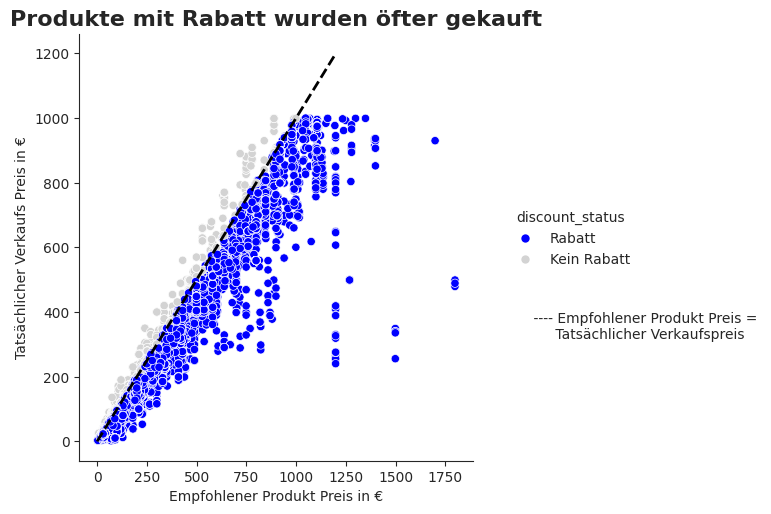

In [75]:
# Kopie erstellen
products_df = products_cl.copy()
orderlines_df = orderlines_qu.copy()

# Mergen

products_and_orderlines_df = products_df.merge(orderlines_df, left_on = 'sku', right_on = 'sku', how = 'inner')

products_and_orderlines_df['discount'] = products_and_orderlines_df['price'] - products_and_orderlines_df['unit_price']

products_and_orderlines_df.loc[(products_and_orderlines_df['discount'] > 0), 'discount_status'] = 'Rabatt'

products_and_orderlines_df.loc[(products_and_orderlines_df['discount'] <= 0), 'discount_status'] = 'Kein Rabatt'

products_and_orderlines_df

##### Plot


### Ein relationaler Plot, da ich auf dr x und y Achse 2 numerische Werte vergleiche
### Exploratorisch:
sns.set_style('ticks')     # Damit Achsen bleiben

p_and_ol_plot = sns.relplot(
    data = products_and_orderlines_df,
    x = 'price',
    y = 'unit_price',
    hue = 'discount_status',
    palette = {'Rabatt': 'blue', 'Kein Rabatt': 'lightgray'}
);

p_and_ol_plot.ax.set_title(
    'Produkte mit Rabatt wurden öfter gekauft',
    fontsize = 16,
    fontweight = 'bold'
)


p_and_ol_plot.set_axis_labels(
    'Empfohlener Produkt Preis in €',
    'Tatsächlicher Verkaufs Preis in €'
)

ax = p_and_ol_plot.ax
ax.grid(False)

p_and_ol_plot.legend.set_bbox_to_anchor((1.02, 0.55))

# Linie noch hinzufügen
import matplotlib.pyplot as plt
ax = p_and_ol_plot.ax
ax.plot([0, 1200], [0, 1200],
        color = 'black',
        linestyle = '--',
        linewidth = 2,
        label = 'Empfohlener Produkt Preis = Tatsächlicher Verkaufspreis'
  )

# Legenden Text für die Linie extra manuell hinzufügen
ax.text(
    1.02, 0.35,
    '            ---- Empfohlener Produkt Preis = \n                 Tatsächlicher Verkaufspreis',
    transform = ax.transAxes,
    fontsize = 10,
    ha = 'left',
    va = 'top'
)

#Damit der Hintergrund weiß ist
ax.set_facecolor('white')

##Plot 2 Summe der Rabatte und höchster Punkt

Bereinigte Daten laden

In [76]:
# orders_cl.csv Bereinigte Datei
url = "https://drive.google.com/file/d/1-AzqkigukXyFdjHL5B0nBNRxL_6Rmq3h/view?usp=share_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orders_cl = pd.read_csv(path)

# orderlines_cl.csv Bereinigte Datei
url = "https://drive.google.com/file/d/1jJr61C7l8gM67uImo9gfWAxRfMMVlgAU/view?usp=share_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
orderlines_cl = pd.read_csv(path)

# products_cl.csv Bereinigte Datei
url = "https://drive.google.com/file/d/1mOa_q_KybqyjGzawPg4hib8aDP1Daw5t/view?usp=share_link"
path = "https://drive.google.com/uc?export=download&id="+url.split("/")[-2]
products_cl = pd.read_csv(path)

Kopie erstellen

In [77]:
  # Kopie erstellen orders_df von orders_cl
  orders_df = orders_cl.copy()

  # Kopie erstellen orderlines_df von orderlines_cl
  orderlines_df = orderlines_cl.copy()

  # Kopie erstellen products_df von products_cl
  products_df = products_cl.copy()

Nochmal discount berechnen und Tabellen erstellen

In [78]:
# discount = products.price - orderlines.unit_price
# Mergen von orderlines und products und discount berechnen als neue Spalte

products_and_orderlines_df = products_df.merge(orderlines_df, left_on = 'sku', right_on = 'sku', how = 'left')

products_and_orderlines_df['discount'] = products_and_orderlines_df['price'] - products_and_orderlines_df['unit_price']

Daten in richtigen Datentyp konvertieren

In [79]:
# bei id und id_order steht .0 am Ende der Zahl. Dies wird entfernt.
products_and_orderlines_df.info()

# Konvertieren
products_and_orderlines_df['id'] = products_and_orderlines_df['id'].astype('Int64')
products_and_orderlines_df['id_order'] = products_and_orderlines_df['id_order'].astype('Int64')

products_and_orderlines_df


# Konvertieren von date in Datumformat
products_and_orderlines_df['date'] = pd.to_datetime(products_and_orderlines_df["date"])

products_and_orderlines_df.info()

min_date = products_and_orderlines_df['date'].min()
max_date = products_and_orderlines_df['date'].max()
zeitraum = max_date - min_date

zeitraum

print(f'Das Minimale Datum ist: {min_date}. \nDas Maximale Datum ist: {max_date}. \nDer Zeitraum beträgt: {zeitraum}.')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52369 entries, 0 to 52368
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   sku               52369 non-null  object 
 1   name              52369 non-null  object 
 2   desc              52369 non-null  object 
 3   price             52369 non-null  float64
 4   in_stock          52369 non-null  int64  
 5   type              52355 non-null  object 
 6   id                51337 non-null  float64
 7   id_order          51337 non-null  float64
 8   product_id        51337 non-null  float64
 9   product_quantity  51337 non-null  float64
 10  unit_price        51337 non-null  float64
 11  date              51337 non-null  object 
 12  unit_price_total  51337 non-null  float64
 13  discount          51337 non-null  float64
dtypes: float64(8), int64(1), object(5)
memory usage: 5.6+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52369 entries, 0 to 52368
D

Are there seasonal patterns in the evolution of sales?

Text(30, -15, 'Nov 2017\n231.8 Tsd €')

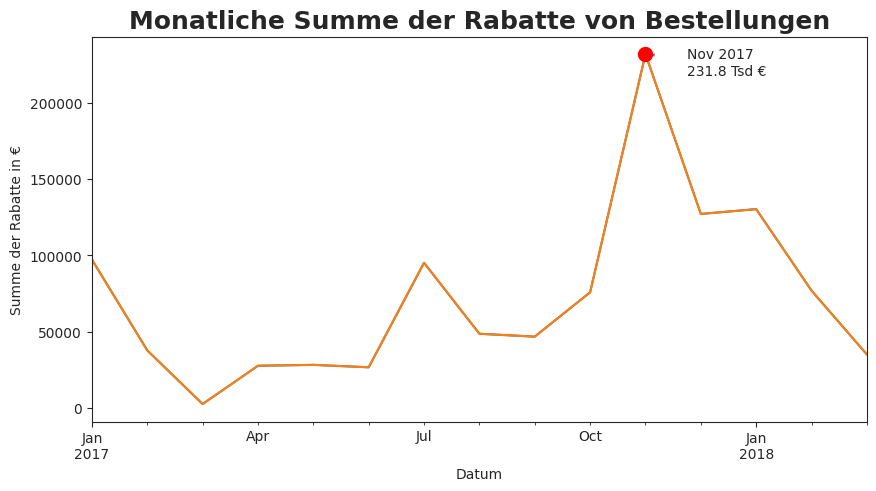

In [80]:
import matplotlib.pyplot as plt
# Spalten Gruppieren nach Monate

# Monat Spalte erstellen
products_and_orderlines_df['Month'] = products_and_orderlines_df['date'].dt.month_name()

# Jahr Spalte erstellen
products_and_orderlines_df['Year'] = products_and_orderlines_df['date'].dt.year

# Jahr Spalte umwandeln
products_and_orderlines_df['Year'] = products_and_orderlines_df['Year'].astype('Int64')

# Jahr und Monat als Spalte erstellen
products_and_orderlines_df['Year_and_Month_As_String'] = products_and_orderlines_df["date"].dt.strftime("%b %y")

#Gruppieren mit resample und plotten
products_and_orderlines_df.resample('ME', on = 'date')['discount'].sum().plot(figsize = (10,5), title = "Anzahl der Rabatte von Bestellungen", xlabel= 'Datum', ylabel = 'Rabatte in €')

# In der Winterzeit sind die meisten Verkauften Produkte.
# Dies kann auch daran liegen, dass im Winter immer die neusten iphone Modelle erscheinen
# Markieren des höchsten Punktes mit Datum
monthly_discount_grouped = products_and_orderlines_df.resample('ME', on = 'date')['discount'].sum()

# Index (Datum) des höchsten Wertes rausfinden
max_date = monthly_discount_grouped.idxmax()
max_value = monthly_discount_grouped.max()

# Standart Style hinzufügen und benutzen
plt.style.use('default')

#Achsen sollen schwarz bleiben und nicht verschwinden
sns.set_style('ticks')

# Die Achse des 1. Plots in ax speichern
ax = monthly_discount_grouped.plot(figsize = (10,5), title = "Monatliche Summe der Rabatte von Bestellungen", xlabel= 'Datum', ylabel = 'Summe der Rabatte in €')

# Weißer Hintergrund und keine Gitterlinie
ax.set_facecolor('white')
ax.grid(False)

# Den Titel fett und größer
ax.set_title(
    "Monatliche Summe der Rabatte von Bestellungen",
    fontsize = 18,
    fontweight = 'bold'
)

# Den höchsten Punkt darauf markieren. max_date ist x Koordinate, max_value ist y Koordinate
ax.scatter(max_date, max_value, color = 'red', s = 100, zorder = 5)

# Datum und Wert neben dem roten Piunkt hinzufügen. Wieder mit ax was wie ein Blatt Papier ist auf dem man zeichnet
ax.annotate(
    f'{max_date.strftime('%b %Y')}\n{max_value/1000:.1f} Tsd €',
    xy = (max_date, max_value),                                    # Wo ist der markierte Punkt?
    xytext = (30,-15),                                             # Position der Beschriftung Abstand zum Punkt
    textcoords = 'offset points',                                  # Wie wird die Position von x und y interpretiert. Hier: als Abstand Koordinaten zum markierten Punkt
    arrowprops = dict (arrowstyle = '-|>')                         # Wie sieht der Pfeil aus der zum markierten Punkt zeigt
)

# Beobachtung: Die höchste Summe der gewährten Rabatte wurde im November 2017 erzeilt und betrug 231,8 Tsd€

#Plot Stephan

In [81]:
# =====================================================================
# VORBEREITUNG: Merge für korrekte Zeitanalysen und echte Umsätze
# =====================================================================

# 1. Merge von orders_qu (enthält created_date und state) mit den Bestellzeilen
df_master = products_and_orderlines_df.merge(orders_qu, left_on='id_order', right_on='order_id', how='inner')

# 2. Filtern auf erfolgreich abgeschlossene Bestellungen (EXTREM WICHTIG für KPIs!)
df_master = df_master[df_master['state'] == 'Completed'].copy()

# 3. Datumstyp konvertieren
df_master['created_date'] = pd.to_datetime(df_master['created_date'])

# 4. Echten Zeilen-Umsatz berechnen (Verkaufte Menge * bezahlter Einzelpreis)
df_master['line_total'] = df_master['product_quantity'] * df_master['unit_price']

display("Datenbasis bereingt")


'Datenbasis bereingt'


# FRAGE 1 & 2:
Welchen Zeitraum umfasst der Datensatz und wie hoch ist der Gesamtumsatz?

In [82]:
min_date = df_master['created_date'].min().strftime('%d.%m.%Y')
max_date = df_master['created_date'].max().strftime('%d.%m.%Y')
total_revenue = df_master['line_total'].sum()
print(f"--- ENIAC BUSINESS KPIs ---")
print(f"Zeitraum der Daten: {min_date} bis {max_date}")
print()
print(f"Gesamtumsatz: {total_revenue:,.2f} €".replace(',', 'X').replace('.', ',').replace('X', '.'))

--- ENIAC BUSINESS KPIs ---
Zeitraum der Daten: 01.01.2017 bis 14.03.2018

Gesamtumsatz: 7.006.635,14 €


## Frage 1 & 2 in Plotform

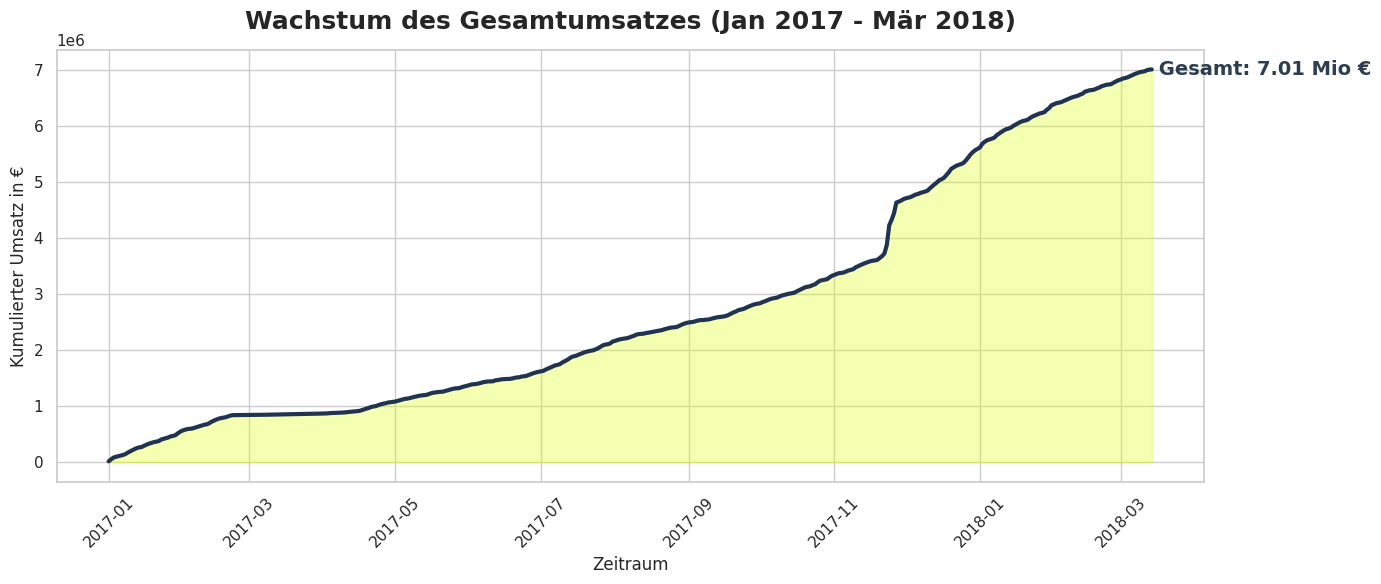

In [83]:
# =====================================================================
# PLOT ZU FRAGE 1 & 2: Kumulierter Gesamtumsatz über den gesamten Zeitraum
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Täglichen Umsatz berechnen und aufsummieren (kumulieren)
daily_revenue = df_master.groupby(df_master['created_date'].dt.date)['line_total'].sum().reset_index()
daily_revenue['cumulative_revenue'] = daily_revenue['line_total'].cumsum()

plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")

# Liniendiagramm mit gefüllter Fläche (Area Chart)
sns.lineplot(data=daily_revenue, x='created_date', y='cumulative_revenue', color='#20344f', linewidth=3)
plt.fill_between(daily_revenue['created_date'], daily_revenue['cumulative_revenue'], color='#e0ff01', alpha=0.3)

# Den finalen Gesamtumsatz als fetten Text am Ende des Graphen markieren
final_date = daily_revenue['created_date'].iloc[-1]
final_revenue = daily_revenue['cumulative_revenue'].iloc[-1]
plt.text(final_date, final_revenue, f" Gesamt: {final_revenue/1e6:.2f} Mio €",
         fontsize=14, fontweight='bold', color='#2c3e50', va='center')

plt.title('Wachstum des Gesamtumsatzes (Jan 2017 - Mär 2018)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Zeitraum', fontsize=12)
plt.ylabel('Kumulierter Umsatz in €', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Kommentar:
# "Ein klassischer 'Up and to the right' Chart. Das Board sieht auf einen Blick den zeitlichen Rahmen
# und das Erreichen unseres Umsatz-Meilensteins."


# Frage 3: Saisonale Muster
**Gibt es saisonale Muster in der Umsatzentwicklung?**

Visualisiert den Monatsumsatz als Liniendiagramm. Der Code setzt automatisch Highlight-Marker für Black Friday und Weihnachten!

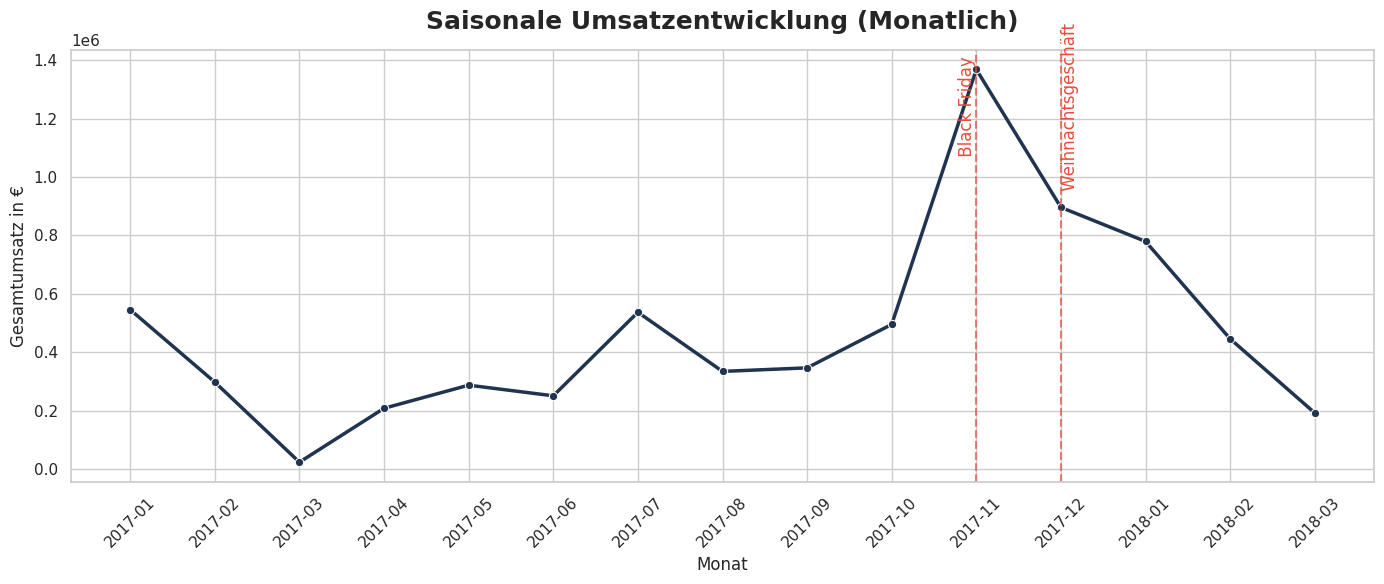

In [84]:
# =====================================================================
# FRAGE 3: Gibt es saisonale Muster in der Umsatzentwicklung?
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Umsatz pro Jahr-Monat aggregieren
df_master['year_month'] = df_master['created_date'].dt.to_period('M').astype(str)
monthly_revenue = df_master.groupby('year_month')['line_total'].sum().reset_index()

# Visualisierung (Linechart)
plt.figure(figsize=(14, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(data=monthly_revenue, x='year_month', y='line_total', marker='o', color='#20344f', linewidth=2.5)

# Sales-Fokus: Wichtige Events im Chart hervorheben
plt.axvline(x='2017-11', color='#e74c3c', linestyle='--', alpha=0.7)
plt.axvline(x='2017-12', color='#e74c3c', linestyle='--', alpha=0.7)
plt.text('2017-11', monthly_revenue['line_total'].max() * 0.9, ' Black Friday', color='#e74c3c', rotation=90, va='center', ha='right', fontsize=12)
plt.text('2017-12', monthly_revenue['line_total'].max() * 0.9, ' Weihnachtsgeschäft', color='#e74c3c', rotation=90, va='center', ha='left', fontsize=12)

plt.title('Saisonale Umsatzentwicklung (Monatlich)', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Monat', fontsize=12)
plt.ylabel('Gesamtumsatz in €', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Kommentar:
# "Wir sehen massive Umsatz-Peaks im November (Black Friday) und Dezember (Weihnachtsgeschäft)."


# Frage 4: Was sind die meistverkauften Produkte?

Meistverkaufte Produkte nach **Menge**

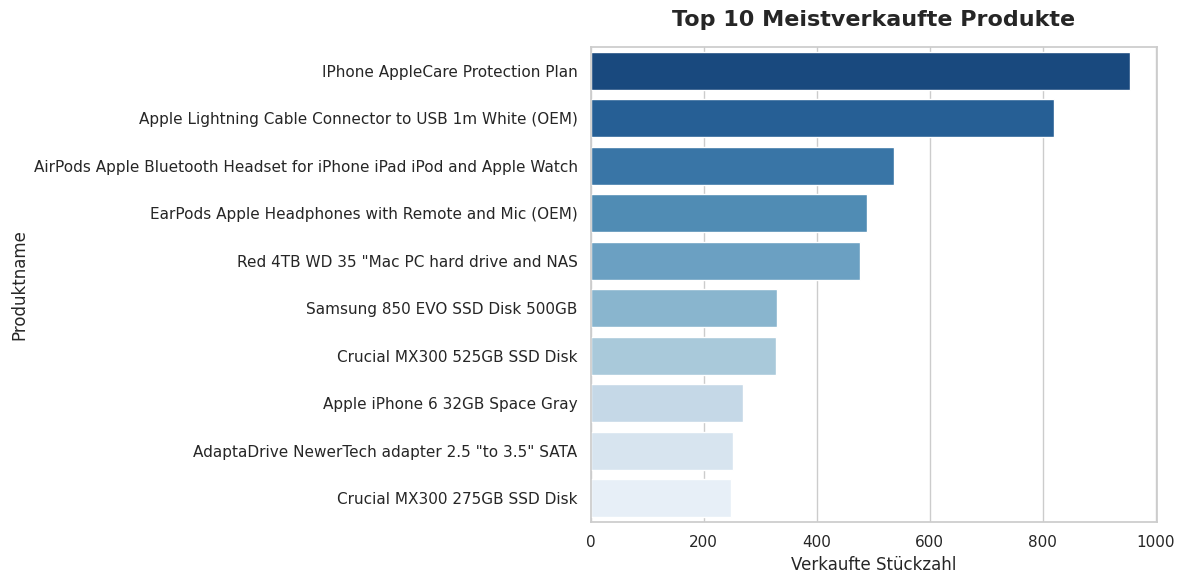

In [85]:
top_products_qty = df_master.groupby('name')['product_quantity'].sum().nlargest(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_qty, y='name', x='product_quantity', palette='Blues_r', hue='name', legend=False)
plt.title('Top 10 Meistverkaufte Produkte', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Verkaufte Stückzahl', fontsize=12)
plt.ylabel('Produktname', fontsize=12)
plt.tight_layout()
plt.show()
# Business Kommentar:
# "Zubehör (Kopfhörer, Keyboards, Mäuse) ist der absolute Volumen-Treiber zur Kundenakquise."

#FRAGE 5: Welche Produkte generieren den größten Umsatz?
Das ist die wichtigste Grafik fürs Board. Hier sehen wir unsere Cash-Cows.



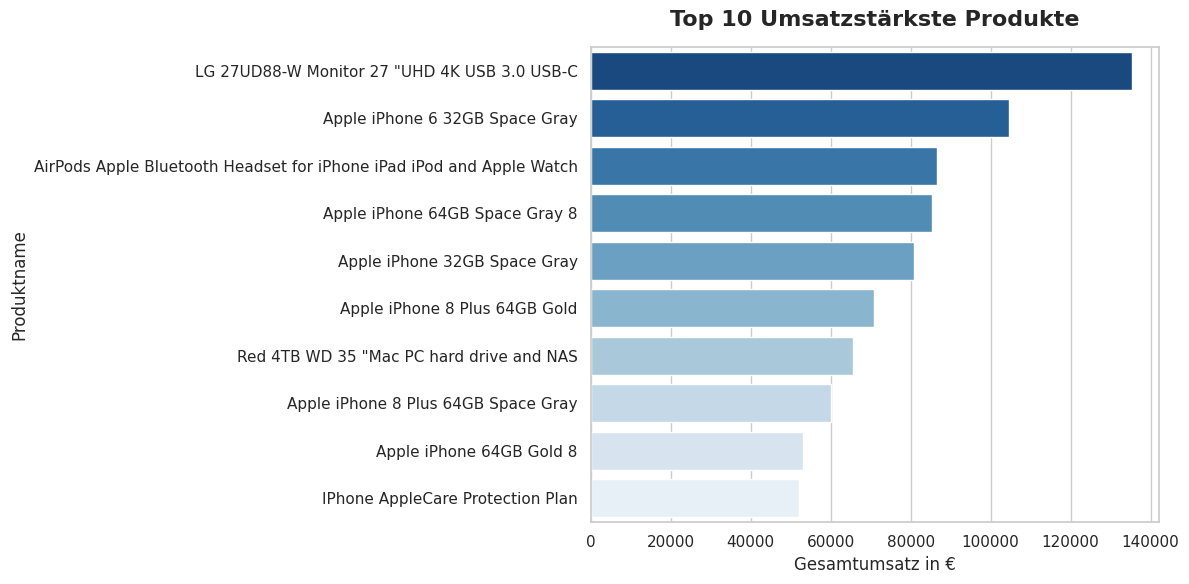

In [86]:
top_products_rev = df_master.groupby('name')['line_total'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products_rev, y='name', x='line_total', palette='Blues_r', hue='name', legend=False)

plt.title('Top 10 Umsatzstärkste Produkte', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Gesamtumsatz in €', fontsize=12)
plt.ylabel('Produktname', fontsize=12)
plt.tight_layout()
plt.show()

# Business Kommentar:
# "Apple Hardware (iPhones) bringt das Geld. Sie haben weniger Volumen, aber den größten Business Impact."


# BONUS FRAGE:
## Wie viele Produkte sind rabattiert & wie hoch ist der % Rabatt?

In [87]:

# Wir betrachten nur Produkte, bei denen der bezahlte Preis kleiner ist als der Originalpreis
discounted_orders = df_master[df_master['unit_price'] < df_master['price']].copy()

total_items_sold = len(df_master)
discounted_items_sold = len(discounted_orders)
pct_discounted = (discounted_items_sold / total_items_sold) * 100

# Prozentualen Rabatt berechnen: (Originalpreis - Verkaufspreis) / Originalpreis
discounted_orders['discount_percentage'] = ((discounted_orders['price'] - discounted_orders['unit_price']) / discounted_orders['price']) * 100
avg_discount = discounted_orders['discount_percentage'].mean()

print(f"--- DISCOUNT ANALYSE ---")
print(f"Von {total_items_sold:,} verkauften Artikeln wurden {discounted_items_sold:,} mit einem Rabatt verkauft ({pct_discounted:.1f}%).")
print(f"Der durchschnittliche Rabatt auf diese Artikel betrug {avg_discount:.1f} %.")


--- DISCOUNT ANALYSE ---
Von 51,337 verkauften Artikeln wurden 47,513 mit einem Rabatt verkauft (92.6%).
Der durchschnittliche Rabatt auf diese Artikel betrug 22.8 %.


## Bonusfrage in Plot

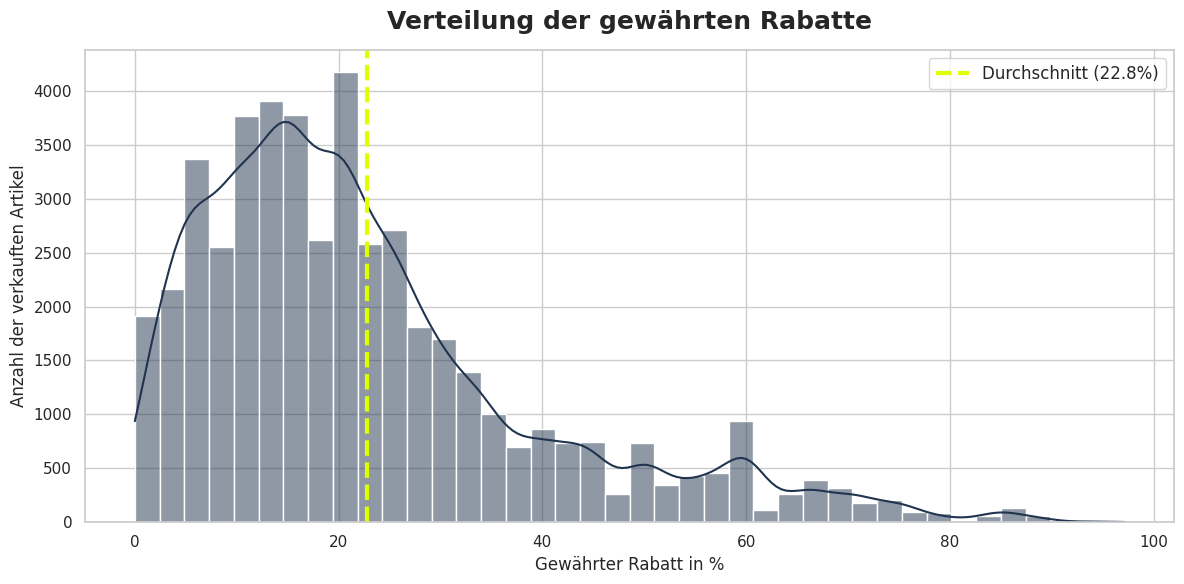

'\ndunkelblau: #20344f;\nblaugrau: #52627b;\nhellgrau: #edeef0;\nlemon: #e0ff01;\nweiss: #ffffff;\ntext-dark: #333;\ngruen: #2ECC71;\nrot: #E74C3C;\n'

In [88]:
# =====================================================================
# PLOT ZUR BONUS FRAGE: Verteilung der Rabatte (Wie hoch sind die Rabatte?)
# =====================================================================

# Wir betrachten wieder nur rabattierte Bestellungen und berechnen %
discounted_orders = df_master[df_master['unit_price'] < df_master['price']].copy()
discounted_orders['discount_percentage'] = ((discounted_orders['price'] - discounted_orders['unit_price']) / discounted_orders['price']) * 100

avg_discount = discounted_orders['discount_percentage'].mean()

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Histogramm mit Dichtekurve (KDE)
sns.histplot(data=discounted_orders, x='discount_percentage', bins=40, color='#20344f', kde=True, edgecolor="white")

# Rote Linie für den Durchschnitt einzeichnen
plt.axvline(x=avg_discount, color='#e0ff01', linestyle='--', linewidth=3, label=f'Durchschnitt ({avg_discount:.1f}%)')

plt.title('Verteilung der gewährten Rabatte', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Gewährter Rabatt in %', fontsize=12)
plt.ylabel('Anzahl der verkauften Artikel', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

"""
dunkelblau: #20344f;
blaugrau: #52627b;
hellgrau: #edeef0;
lemon: #e0ff01;
weiss: #ffffff;
text-dark: #333;
gruen: #2ECC71;
rot: #E74C3C;
"""

########OPTIONAL

# Business-Insight Kommentar:
# "Zeigt dem Management sofort, in welchem Rahmen wir rabattieren.
# Ein dunkeklblauer Strich markiert den Durchschnitt, aber die Kurve zeigt, wo unsere 'Sweet Spots' liegen."


# Baseline Analyse

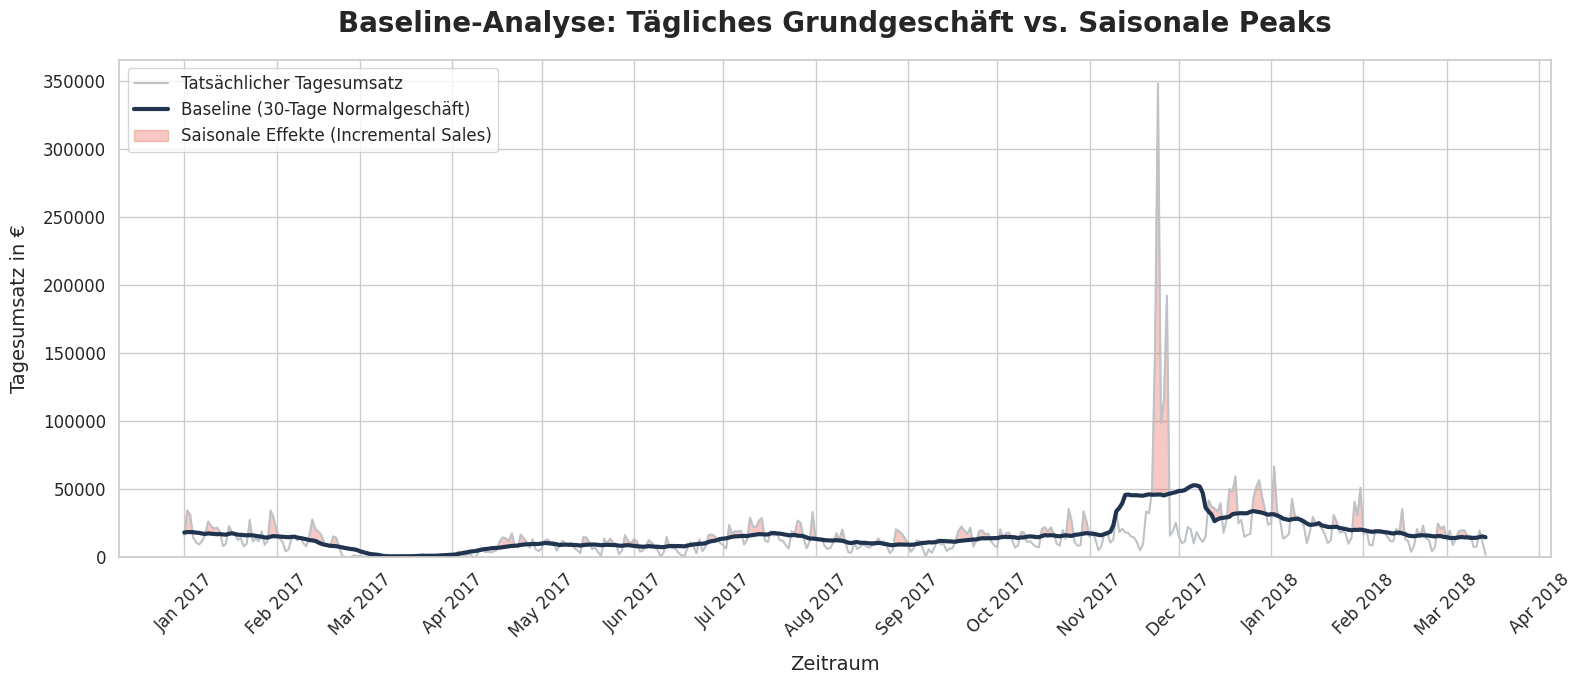

In [89]:
# =====================================================================
# ZUSATZ-PLOT: Baseline-Analyse (Normalgeschäft vs. Saisonale Peaks)
# =====================================================================
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Tagesumsätze aggregieren
df_master['date'] = df_master['created_date'].dt.date
daily_revenue = df_master.groupby('date')['line_total'].sum().reset_index()

# Datum als Index setzen für die gleitende Durchschnittsberechnung
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])
daily_revenue.set_index('date', inplace=True)
daily_revenue = daily_revenue.sort_index()

# 2. Berechne 30-Tage Baseline (Gleitender Durchschnitt)
# Das glättet extreme Ausreißer (wie Black Friday) weg und zeigt das "Normalgeschäft"
daily_revenue['baseline'] = daily_revenue['line_total'].rolling(window=30, center=True, min_periods=1).mean()

# 3. Zeichne den Graphen
plt.figure(figsize=(16, 7))

# Linie 1: Der echte, schwankende Tagesumsatz (im Hintergrund in Grau)
plt.plot(daily_revenue.index, daily_revenue['line_total'], color='#bdc3c7', label='Tatsächlicher Tagesumsatz', linewidth=1.5)

# Linie 2: Die geglättete Baseline (Dunkelblau, dick)
plt.plot(daily_revenue.index, daily_revenue['baseline'], color='#20344f', label='Baseline (30-Tage Normalgeschäft)', linewidth=3)

# Highlight: Rot einfärben, wenn der Umsatz extrem über die Baseline hinausschießt (Incremental Sales)
plt.fill_between(daily_revenue.index,
                 daily_revenue['baseline'],
                 daily_revenue['line_total'],
                 where=(daily_revenue['line_total'] > daily_revenue['baseline']),
                 interpolate=True, color='#e74c3c', alpha=0.3, label='Saisonale Effekte (Incremental Sales)')

plt.title('Baseline-Analyse: Tägliches Grundgeschäft vs. Saisonale Peaks', fontsize=20, fontweight='bold', pad=20)
plt.xlabel('Zeitraum', fontsize=14, labelpad=10)
plt.ylabel('Tagesumsatz in €', fontsize=14, labelpad=10)
plt.legend(fontsize=12, loc='upper left')

# X-Achse schön als Monat/Jahr formatieren
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.ylim(bottom=0)

plt.tight_layout()
plt.show()

# Business-Insight Kommentar:
# "Das rote Feld ist reiner 'Incremental Revenue' – Umsatz, den wir nur der Saisonalität verdanken.
# Die blaue Linie zeigt, ob wir in der Substanz wachsen."


## Umsatz nach Prod Kate

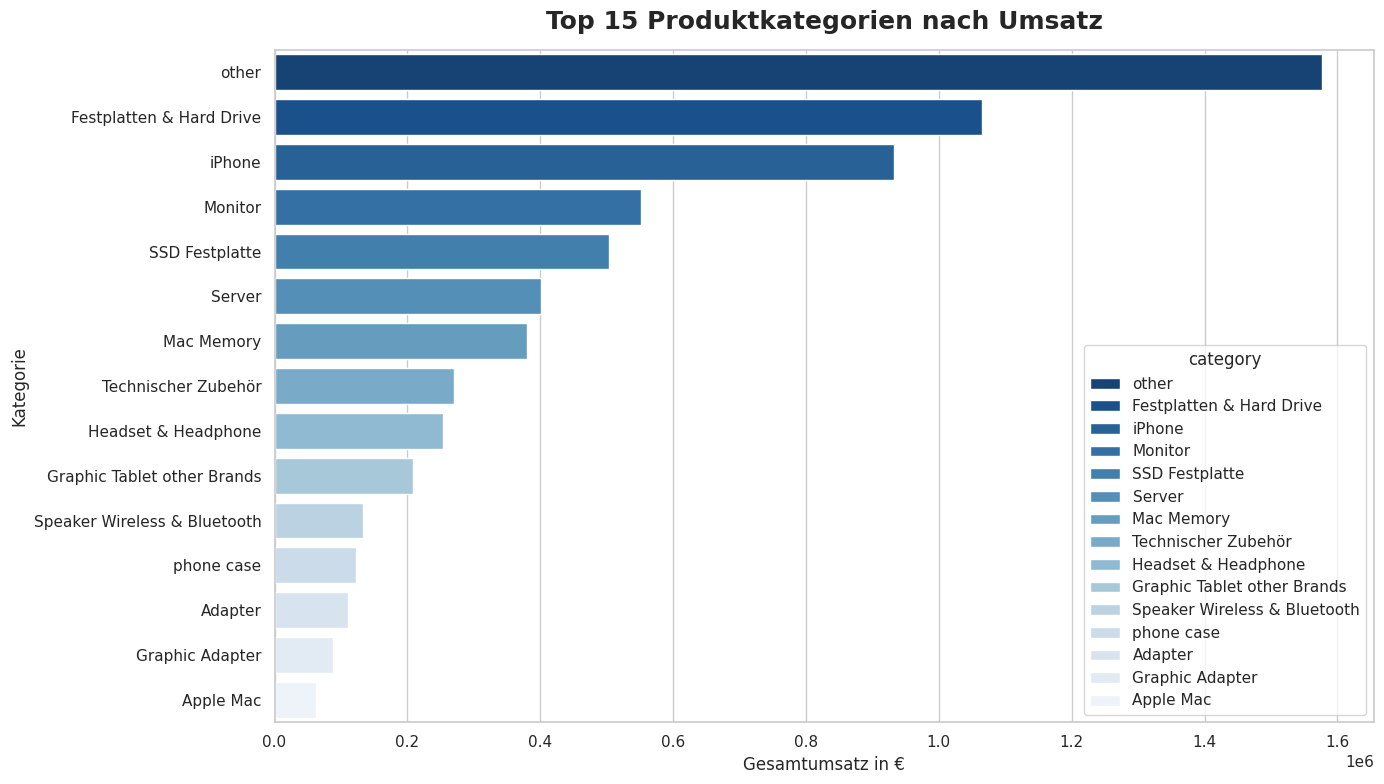

In [90]:
# =====================================================================
# ZUSATZ-PLOT: Umsatzstärkste Produktkategorien
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

if 'category' not in df_master.columns:
    df_master = df_master.merge(product_category_df[['sku', 'category']], on='sku', how='left')

# Falls durch den Merge leere Felder entstehen, nennen wir sie 'other'
df_master['category'] = df_master['category'].fillna('other')

# 2. Umsatz pro Kategorie berechnen
category_revenue = df_master.groupby('category')['line_total'].sum().reset_index()

#   30 Kategorien gebaut, filtern wir für den Plot nur die Top 15 heraus
top_category_revenue = category_revenue.sort_values(by='line_total', ascending=False).head(15)

# 3. Visualisierung (Barchart)
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# Barchart in  Blau
sns.barplot(data=top_category_revenue, y='category', x='line_total', palette='Blues_r', hue='category', legend=True)

plt.title('Top 15 Produktkategorien nach Umsatz', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Gesamtumsatz in €', fontsize=12)
plt.ylabel('Kategorie', fontsize=12)
plt.tight_layout()
plt.show()

# Business Kommentar:
# "Dank der tiefen Type-Zuordnung sehen wir exakt, welche Produktsegmente (z.B. MacBooks, Apple Mac)
# unseren Euro-Umsatz treiben, auch wenn die Stückzahlen vielleicht bei 'phone case' höher liegen."


In [91]:
display(product_category_df['category'].unique())


array(['other', 'Mac Memory', 'Used Apple Accessoire',
       'Headset & Headphone', 'Wifi Adapter', 'Cover for Mac Book',
       'Graphic Adapter', 'phone case', 'Technischer Zubehör',
       'ipad Case', 'Monitor', 'Digital Pen', 'Festplatten & Hard Drive',
       'Apple Mac', 'Server', 'Graphic Tablet other Brands',
       'Micro Memory Card', 'SSD Festplatte', 'Screen Protector',
       'Speaker Wireless & Bluetooth', 'External Battery',
       'Open Produkte', 'Charger', 'Adapter', 'iPhone',
       'Apple Watch Accessiore', 'Apple iMac Device', 'Mac Book Pro'],
      dtype=object)

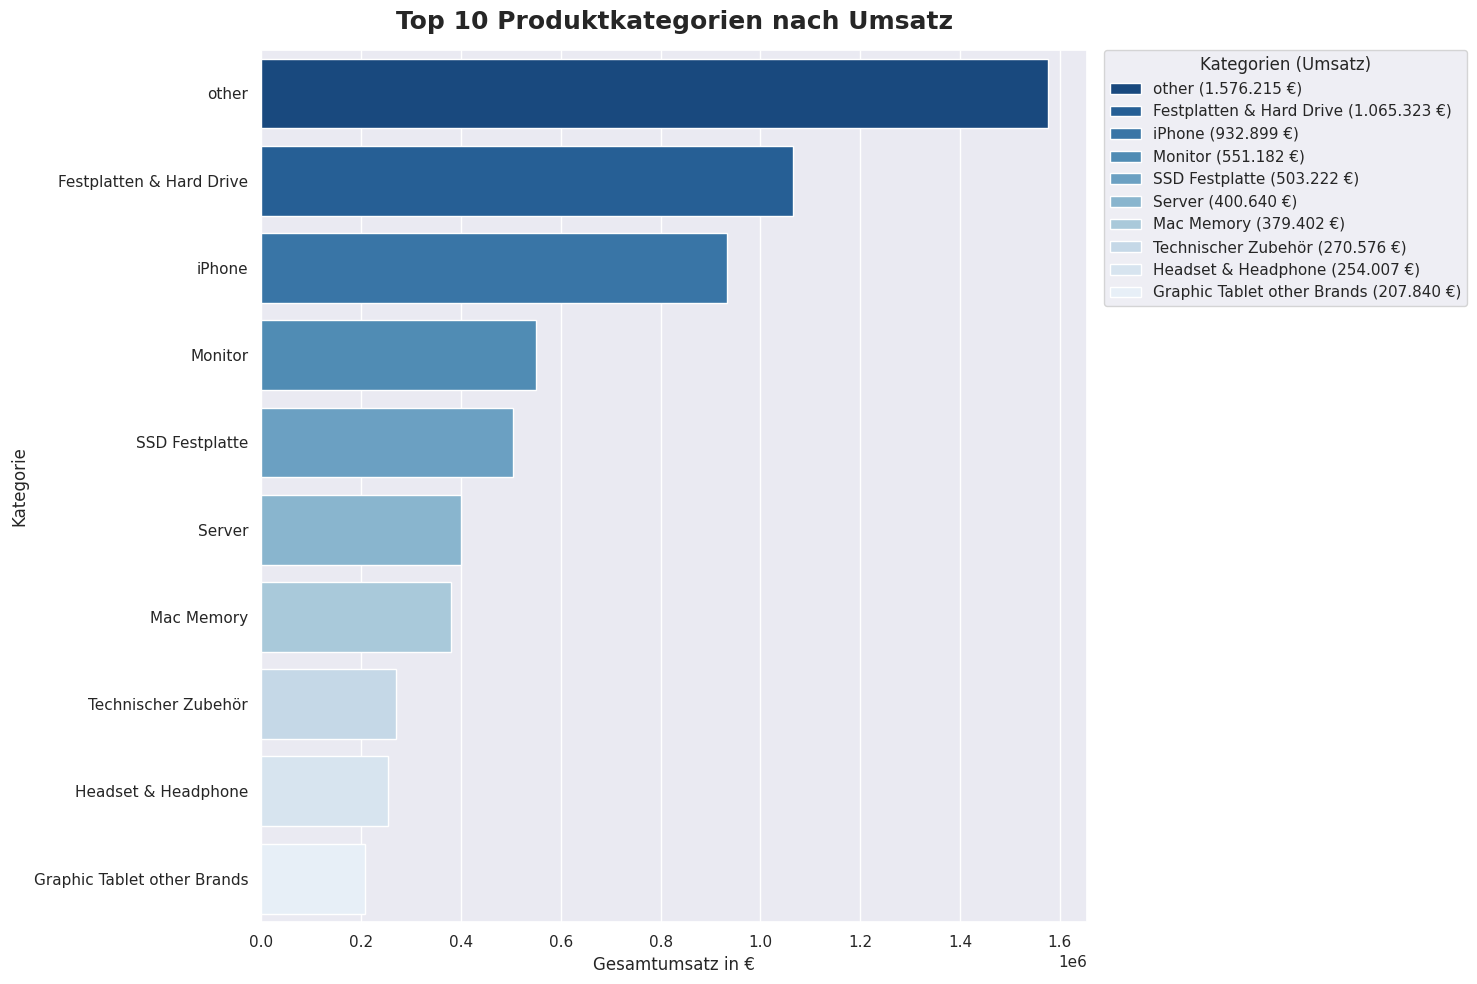

In [92]:
# =====================================================================
# ZUSATZ-PLOT: Umsatzstärkste Produktkategorien
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

if "category" not in df_master.columns:
    df_master = df_master.merge(
        product_category_df[["sku", "category"]], on="sku", how="left"
    )

# Falls durch den Merge leere Felder entstehen, nennen wir sie 'other'
df_master["category"] = df_master["category"].fillna("other")

# 2. Umsatz pro Kategorie berechnen
category_revenue = (
    df_master.groupby("category")["line_total"].sum().reset_index()
)

#   30 Kategorien gebaut, filtern wir für den Plot nur die Top 15 heraus
top_category_revenue = category_revenue.sort_values(
    by="line_total", ascending=False
).head(10)


top_category_revenue["category_with_sum"] = top_category_revenue.apply(
    lambda row: f"{row['category']} ({row['line_total']:,.0f} €)".replace(
        ",", "."
    ),
    axis=1,
)
# -------------------------------------------------------------

plt.figure(figsize=(15, 10))  #
sns.set_theme(style="darkgrid")

# https://seaborn.pydata.org/generated/seaborn.set_theme.html

sns.barplot(
    data=top_category_revenue,
    y="category",
    x="line_total",
    palette="Blues_r",
    hue="category_with_sum",
    legend=True,
)

plt.title(
    "Top 10 Produktkategorien nach Umsatz",
    fontsize=18,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Gesamtumsatz in €", fontsize=12)
plt.ylabel("Kategorie", fontsize=12)

plt.legend(
    title="Kategorien (Umsatz)",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.tight_layout()
plt.show()



In [93]:
products_and_orderlines_df.head(1)

,sku,name,desc,price,in_stock,type,id,id_order,product_id,product_quantity,unit_price,date,unit_price_total,discount,Month,Year,Year_and_Month_As_String
0,RAI0007,Silver Rain Design mStand Support,Aluminum support compatible with all MacBook,59.99,1,8696,1121326,300551,0.00,1.00,54.99,2017-01-02 13:34:30,54.99,5.00,January,2017,Jan 17
